# Match Time Series Analysis

Two views of match dynamics using time-bucketed metrics:

- **Section 1** — Single Match Inspector: per-team attack depth and death rate over absolute match time.
- **Section 2** — Aggregate Per-Map View: all matches on a map overlaid on normalized time `[0, 1]`.
- **Section 3** — Push-Pull Summary: Pearson correlation between teams' attack depths (map quality metric).

**Timestamp note:** All event timestamps in the database are elapsed seconds since match start.
`position_events.timestamp` is therefore used directly as `tick_t_s` — no conversion required.

In [1]:
import os, sys
# Change to repo root so all relative paths resolve correctly.
# Works whether launched from notebooks/ or the repo root.
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    os.chdir("..")

import math
import duckdb
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Global tunables ───────────────────────────────────────────────────────────
BUCKET_SIZE_S = 60          # bucket width in seconds (used across all sections)
OUTPUT_DIR    = Path("output")
DB_PATH       = Path("match_analysis/metadata.db")

OUTPUT_DIR.mkdir(exist_ok=True)
print(f"DuckDB: {DB_PATH}  |  bucket: {BUCKET_SIZE_S}s  |  output: {OUTPUT_DIR}")

DuckDB: match_analysis/metadata.db  |  bucket: 60s  |  output: output


In [2]:
# ── Helper: DB connection ─────────────────────────────────────────────────────

def open_db(read_only=True):
    return duckdb.connect(str(DB_PATH), read_only=read_only)


# ── Helper: team colors ───────────────────────────────────────────────────────

_MINECRAFT_COLORS = {
    "dark_red":    "#AA0000", "dark red":    "#AA0000",
    "red":         "#FF5555",
    "gold":        "#FFAA00",
    "yellow":      "#DDDD00",
    "dark_green":  "#00AA00", "dark green":  "#00AA00",
    "green":       "#55FF55",
    "aqua":        "#55FFFF",
    "dark_aqua":   "#00AAAA", "dark aqua":   "#00AAAA",
    "dark_blue":   "#0000AA", "dark blue":   "#0000AA",
    "blue":        "#5555FF",
    "light_purple":"#FF55FF", "light purple":"#FF55FF",
    "dark_purple": "#AA00AA", "dark purple": "#AA00AA",
    "white":       "#FFFFFF",
    "gray":        "#AAAAAA",
    "dark_gray":   "#555555", "dark gray":   "#555555",
    "black":       "#000000",
}

def get_team_colors(conn, map_id: int) -> dict:
    """Return {normalized_team: hex_color} for a map."""
    rows = conn.execute(
        "SELECT team, team_color FROM map_spawns WHERE map_id = ?", [map_id]
    ).fetchall()
    tab10 = [matplotlib.colors.to_hex(c) for c in plt.get_cmap("tab10").colors]
    colors = {}
    tab10_idx = 0
    for team_raw, color_raw in rows:
        team = team_raw.removesuffix("-team")
        # Minecraft palette lookup first
        hex_color = _MINECRAFT_COLORS.get(color_raw)
        if hex_color is None:
            try:
                hex_color = matplotlib.colors.to_hex(color_raw)
            except ValueError:
                hex_color = tab10[tab10_idx % len(tab10)]
                tab10_idx += 1
        colors[team] = hex_color
    return colors


# ── Helper: load match data ───────────────────────────────────────────────────

def load_match_data(conn, match_id: int):
    """Load positions, deaths, wool events, baselines, and match metadata.

    Timestamps in the database are elapsed seconds since match start.
    position_events.timestamp == tick_t_s (no conversion needed).
    """
    meta = conn.execute(
        "SELECT mat.match_id, mat.map_id, mat.match_duration, m.map_slug "
        "FROM matches mat JOIN maps m ON mat.map_id = m.map_id "
        "WHERE match_id = ?", [match_id]
    ).fetchone()
    if meta is None:
        raise ValueError(f"Match {match_id} not found")
    _, map_id, match_duration_s, map_slug = meta

    pos_df = conn.execute("""
        SELECT
            pe.player_id,
            pe.timestamp  AS tick_t_s,
            pe.x, pe.z,
            pe.location_type,
            pts.team
        FROM position_events pe
        LEFT JOIN player_team_segments pts
            ON  pts.player_id   = pe.player_id
            AND pts.match_id    = pe.match_id
            AND pts.start_timestamp <= pe.timestamp
            AND (pts.end_timestamp IS NULL OR pts.end_timestamp >= pe.timestamp)
        WHERE pe.match_id = ? AND pe.location_type != 'void'
        ORDER BY pe.player_id, pe.timestamp
    """, [match_id]).df()

    death_df = conn.execute("""
        SELECT ce.timestamp AS tick_t_s, pts.team
        FROM combat_events ce
        LEFT JOIN player_team_segments pts
            ON  pts.player_id   = ce.player_id
            AND pts.match_id    = ce.match_id
            AND pts.start_timestamp <= ce.timestamp
            AND (pts.end_timestamp IS NULL OR pts.end_timestamp >= ce.timestamp)
        WHERE ce.match_id = ? AND ce.event_type = 4
    """, [match_id]).df()

    wool_df = conn.execute("""
        SELECT we.timestamp AS tick_t_s, we.event_type, pts.team
        FROM wool_events we
        LEFT JOIN player_team_segments pts
            ON  pts.player_id   = we.player_id
            AND pts.match_id    = we.match_id
            AND pts.start_timestamp <= we.timestamp
            AND (pts.end_timestamp IS NULL OR pts.end_timestamp >= we.timestamp)
        WHERE we.match_id = ?
    """, [match_id]).df()

    baselines = conn.execute("""
        SELECT team, wool_id, wool_x, wool_z, baseline_distance
        FROM wool_spawn_baselines
        WHERE map_id = ?
    """, [map_id]).df()

    return {
        "match_id": match_id,
        "map_id": map_id,
        "map_slug": map_slug,
        "match_duration_s": match_duration_s,
        "pos": pos_df,
        "deaths": death_df,
        "wool": wool_df,
        "baselines": baselines,
    }


# ── Helper: per-tick attack depth ─────────────────────────────────────────────

def add_attack_depth(pos_df: pd.DataFrame, baselines: pd.DataFrame) -> pd.Series:
    """Compute per-tick attack depth for every row in pos_df.

    For each tick, depth against enemy wool W is:
        depth(W) = clip(1 - dist2d(tick, wool_W) / baseline_distance, 0, 1)
    attack_depth_tick = max over all enemy wools for that player's team.

    Enemy wools for team T = rows in wool_spawn_baselines where team == T
    (each team must capture these wools, so they are the attacker's targets).
    """
    depths = pd.Series(0.0, index=pos_df.index)
    for team, grp in pos_df.groupby("team"):
        if pd.isna(team):
            continue
        team_baselines = baselines[baselines["team"] == team]
        if team_baselines.empty:
            continue
        px = grp["x"].values.astype(float)
        pz = grp["z"].values.astype(float)
        for _, wb in team_baselines.iterrows():
            dist = np.sqrt((px - wb.wool_x) ** 2 + (pz - wb.wool_z) ** 2)
            depth = np.clip(1.0 - dist / wb.baseline_distance, 0.0, 1.0)
            depths.loc[grp.index] = np.maximum(depths.loc[grp.index].values, depth)
    return depths


# ── Helper: bucketed metrics ──────────────────────────────────────────────────

def compute_bucketed_metrics(
    data: dict,
    bucket_size_s: int = BUCKET_SIZE_S,
    norm: bool = False,
    n_norm_buckets: int = 50,
) -> pd.DataFrame:
    """Compute per-team per-bucket metrics.

    Returns a DataFrame with columns:
        team, bucket, bucket_mid_s (or bucket_norm_mid),
        mean_attack_depth, depth_std, death_rate, n_players

    If norm=True, uses n_norm_buckets equally-spaced buckets on [0, 1]
    and adds bucket_norm_mid instead of bucket_mid_s.
    """
    pos_df  = data["pos"].copy()
    death_df = data["deaths"].copy()
    match_duration_s = data["match_duration_s"]

    # Attack depth per tick
    pos_df["attack_depth"] = add_attack_depth(pos_df, data["baselines"])

    # Assign bucket index
    if norm:
        pos_df["bucket"] = np.minimum(
            (pos_df["tick_t_s"] / match_duration_s * n_norm_buckets).astype(int),
            n_norm_buckets - 1,
        )
        death_df["bucket"] = np.minimum(
            (death_df["tick_t_s"] / match_duration_s * n_norm_buckets).astype(int),
            n_norm_buckets - 1,
        )
        bin_width = match_duration_s / n_norm_buckets
    else:
        pos_df["bucket"] = (pos_df["tick_t_s"] // bucket_size_s).astype(int)
        death_df["bucket"] = (death_df["tick_t_s"] // bucket_size_s).astype(int)
        bin_width = bucket_size_s

    # Per-team per-bucket attack depth
    depth_stats = (
        pos_df.groupby(["team", "bucket"])["attack_depth"]
        .agg(["mean", "std", lambda x: x.index.nunique()])
        .rename(columns={"mean": "mean_attack_depth", "std": "depth_std", "<lambda_0>": "_ign"})
        .reset_index()
    )

    # n_players per bucket
    n_players = (
        pos_df.groupby(["team", "bucket"])["player_id"]
        .nunique()
        .rename("n_players")
        .reset_index()
    )

    # Deaths per bucket → death_rate (deaths/second)
    death_counts = (
        death_df.groupby(["team", "bucket"]).size()
        .rename("death_count")
        .reset_index()
    )

    df = (
        depth_stats
        .merge(n_players, on=["team", "bucket"], how="left")
        .merge(death_counts, on=["team", "bucket"], how="left")
    )
    df["death_count"] = df["death_count"].fillna(0)
    df["depth_std"]   = df["depth_std"].fillna(0)
    df["death_rate"]  = df["death_count"] / bin_width

    if norm:
        df["bucket_norm_mid"] = (df["bucket"] + 0.5) / n_norm_buckets
    else:
        df["bucket_mid_s"] = (df["bucket"] + 0.5) * bucket_size_s

    return df

## Section 1 — Single Match Inspector

One panel per team showing:
- **Left y-axis:** `mean_attack_depth` per bucket with ±std shading.
- **Right y-axis (dashed):** `death_rate` (deaths/second).
- **Event markers:** ▲ wool touches, ★ wool captures on the x-axis.
- **Grey dashed line:** match end.

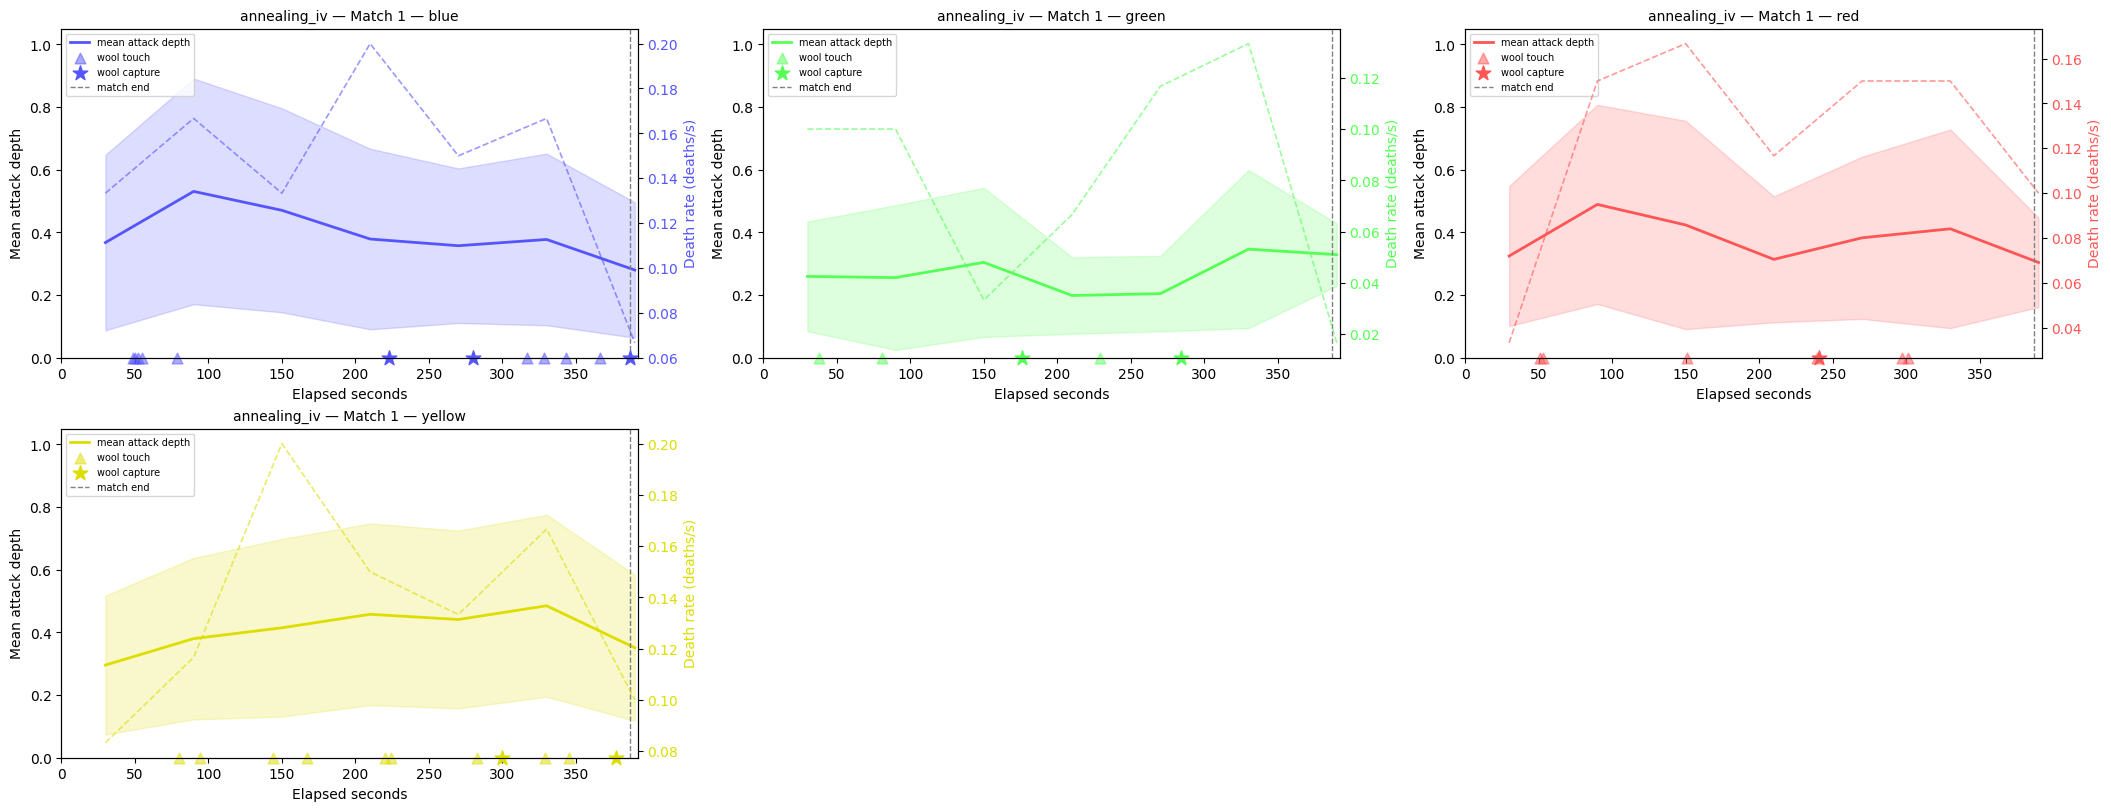

Saved: output/timeseries_match_1.png


In [3]:
# ── CONFIGURE ─────────────────────────────────────────────────────────────────
INSPECT_MATCH_ID = 1   # change to inspect any match
# BUCKET_SIZE_S is inherited from the global cell above
# ─────────────────────────────────────────────────────────────────────────────

conn = open_db()
data = load_match_data(conn, INSPECT_MATCH_ID)
team_colors = get_team_colors(conn, data["map_id"])
conn.close()

metrics = compute_bucketed_metrics(data, bucket_size_s=BUCKET_SIZE_S, norm=False)
teams = sorted(metrics["team"].dropna().unique())
n_teams = len(teams)
match_duration_s = data["match_duration_s"]
map_slug = data["map_slug"]

ncols = min(n_teams, 3)
nrows = math.ceil(n_teams / ncols)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(7 * ncols, 4 * nrows),
    constrained_layout=True,
    squeeze=False,
)

for ax_idx, team in enumerate(teams):
    row, col = divmod(ax_idx, ncols)
    ax = axes[row][col]
    ax2 = ax.twinx()

    color = team_colors.get(team, "#888888")
    tm = metrics[metrics["team"] == team].sort_values("bucket_mid_s")

    if not tm.empty:
        xs = tm["bucket_mid_s"].values
        ys = tm["mean_attack_depth"].values
        sd = tm["depth_std"].values
        dr = tm["death_rate"].values

        # Attack depth line + shaded band
        ax.plot(xs, ys, color=color, lw=2, label="mean attack depth")
        ax.fill_between(xs, ys - sd, ys + sd, color=color, alpha=0.2)

        # Death rate (right axis)
        ax2.plot(xs, dr, color=color, lw=1.2, ls="--", alpha=0.6, label="death rate")

    # Wool event markers
    wool_team = data["wool"][data["wool"]["team"] == team]
    touches  = wool_team[wool_team["event_type"] == 6]["tick_t_s"].values
    captures = wool_team[wool_team["event_type"] == 7]["tick_t_s"].values
    ymin, ymax = ax.get_ylim() if not tm.empty else (0, 1)
    if len(touches):
        ax.scatter(touches,  [0.0] * len(touches),  marker="^", color=color,
                   s=60, alpha=0.5, zorder=5, clip_on=False, label="wool touch")
    if len(captures):
        ax.scatter(captures, [0.0] * len(captures), marker="*", color=color,
                   s=120, zorder=6, clip_on=False, label="wool capture")

    # Match end line
    ax.axvline(match_duration_s, color="grey", ls="--", lw=1, label="match end")

    ax.set_xlim(0, match_duration_s + 5)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Elapsed seconds")
    ax.set_ylabel("Mean attack depth")
    ax2.set_ylabel("Death rate (deaths/s)", color=color)
    ax2.tick_params(axis="y", labelcolor=color)
    ax.set_title(f"{map_slug} — Match {INSPECT_MATCH_ID} — {team}", fontsize=10)
    ax.legend(loc="upper left", fontsize=7)

# Hide unused axes
for ax_idx in range(n_teams, nrows * ncols):
    row, col = divmod(ax_idx, ncols)
    axes[row][col].set_visible(False)

out_path = OUTPUT_DIR / f"timeseries_match_{INSPECT_MATCH_ID}.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

## Section 2 — Aggregate Per-Map View

All matches for a map overlaid on normalized time `[0, 1]`:
- Individual matches as faint lines.
- **Bold line:** median attack depth per norm bucket.
- **Shaded band:** 25th–75th percentile.
- **Rug marks:** wool captures below x-axis, jittered in y.
- **Third panel:** match duration histogram.

Map: outback_outback_edition  |  1 eligible match(es)


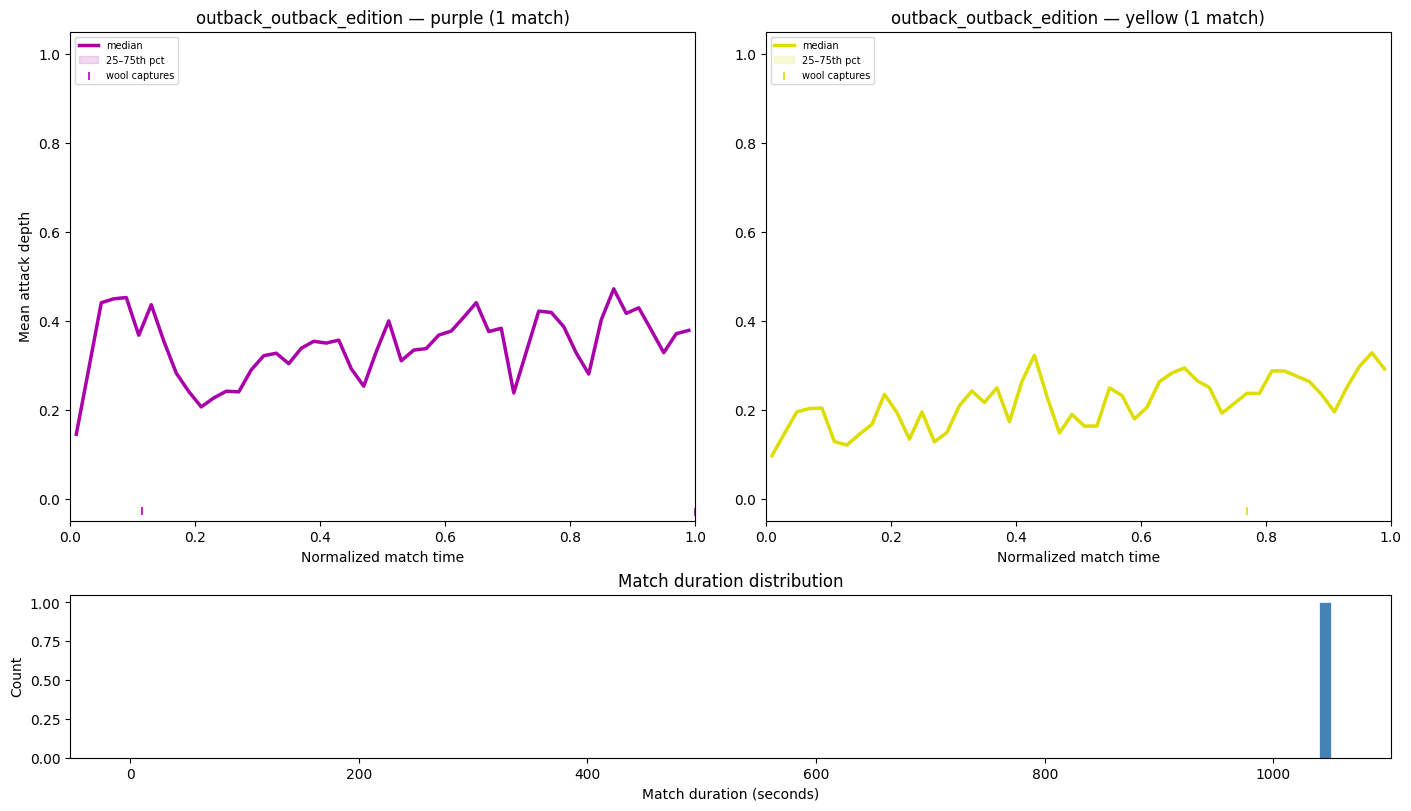

Saved: output/timeseries_aggregate_outback_outback_edition.png


In [4]:
# ── CONFIGURE ─────────────────────────────────────────────────────────────────
AGGREGATE_MAP_SLUG    = "outback_outback_edition"  # change to any map slug
MIN_MATCH_DURATION_S  = 120    # filter very short matches
MAX_MATCHES           = None   # set an integer to cap for performance
N_NORM_BUCKETS        = 50
HIST_BIN_S            = 10     # duration histogram bin width (seconds)
# ─────────────────────────────────────────────────────────────────────────────

conn = open_db()

# Resolve map_id and team colors
map_row = conn.execute(
    "SELECT map_id FROM maps WHERE map_slug = ?", [AGGREGATE_MAP_SLUG]
).fetchone()
if map_row is None:
    raise ValueError(f"Map '{AGGREGATE_MAP_SLUG}' not in database")
agg_map_id = map_row[0]
team_colors_agg = get_team_colors(conn, agg_map_id)

# Fetch eligible match IDs
match_rows = conn.execute("""
    SELECT match_id, match_duration
    FROM matches
    WHERE map_id = ? AND processed = TRUE AND match_duration >= ?
    ORDER BY match_id
""", [agg_map_id, MIN_MATCH_DURATION_S]).fetchall()

if MAX_MATCHES:
    match_rows = match_rows[:MAX_MATCHES]

print(f"Map: {AGGREGATE_MAP_SLUG}  |  {len(match_rows)} eligible match(es)")
match_durations = [r[1] for r in match_rows]

# Collect per-match norm time series
# Structure: {team: list-of-arrays of shape (N_NORM_BUCKETS,)}
series_by_team = {}
wool_cap_norm_by_team = {}   # {team: list of normalized timestamps}

for match_id, _ in match_rows:
    mdata = load_match_data(conn, match_id)
    mmetrics = compute_bucketed_metrics(
        mdata, norm=True, n_norm_buckets=N_NORM_BUCKETS
    )
    teams_in_match = sorted(mmetrics["team"].dropna().unique())
    for team in teams_in_match:
        tm = mmetrics[mmetrics["team"] == team].set_index("bucket")
        # Build full-length array (NaN for missing buckets)
        arr = np.full(N_NORM_BUCKETS, np.nan)
        for b, row in tm.iterrows():
            if 0 <= b < N_NORM_BUCKETS:
                arr[b] = row["mean_attack_depth"]
        series_by_team.setdefault(team, []).append(arr)

        # Wool captures for this match/team
        caps = mdata["wool"][
            (mdata["wool"]["team"] == team) & (mdata["wool"]["event_type"] == 7)
        ]["tick_t_s"].values / mdata["match_duration_s"]
        wool_cap_norm_by_team.setdefault(team, []).extend(caps.tolist())

conn.close()

agg_teams = sorted(series_by_team.keys())
n_matches = len(match_rows)
faint_alpha = max(0.05, 1.0 / n_matches)
norm_xs = (np.arange(N_NORM_BUCKETS) + 0.5) / N_NORM_BUCKETS

ncols = len(agg_teams)
fig = plt.figure(figsize=(7 * ncols, 8), constrained_layout=True)
gs  = fig.add_gridspec(2, ncols, height_ratios=[3, 1])

for t_idx, team in enumerate(agg_teams):
    ax = fig.add_subplot(gs[0, t_idx])
    color = team_colors_agg.get(team, "#888888")
    arrs = np.array(series_by_team[team])  # shape (n_matches, N_NORM_BUCKETS)

    # Faint individual match lines
    for row in arrs:
        ax.plot(norm_xs, row, color=color, alpha=faint_alpha, lw=0.8)

    # Median and percentile band
    med  = np.nanmedian(arrs, axis=0)
    p25  = np.nanpercentile(arrs, 25, axis=0)
    p75  = np.nanpercentile(arrs, 75, axis=0)
    ax.plot(norm_xs, med, color=color, lw=2.5, label="median")
    ax.fill_between(norm_xs, p25, p75, color=color, alpha=0.15, label="25–75th pct")

    # Wool capture rug marks below x-axis (jittered in y)
    cap_times = wool_cap_norm_by_team.get(team, [])
    if cap_times:
        rng = np.random.default_rng(seed=42)
        jitter = rng.uniform(-0.005, 0.005, size=len(cap_times))
        ax.scatter(
            cap_times, [-0.03 + j for j in jitter],
            marker="|", color=color, s=40, alpha=0.8, clip_on=False,
            label="wool captures",
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Normalized match time")
    ax.set_ylabel("Mean attack depth" if t_idx == 0 else "")
    ax.set_title(f"{AGGREGATE_MAP_SLUG} — {team} ({n_matches} match{'es' if n_matches != 1 else ''})")
    ax.legend(loc="upper left", fontsize=7)

# Third panel: match duration histogram
ax_hist = fig.add_subplot(gs[1, :])
max_dur = max(match_durations) if match_durations else 1
bins = np.arange(0, max_dur + HIST_BIN_S, HIST_BIN_S)
ax_hist.hist(match_durations, bins=bins, color="steelblue", edgecolor="white", lw=0.5)
ax_hist.set_xlabel("Match duration (seconds)")
ax_hist.set_ylabel("Count")
ax_hist.set_title("Match duration distribution")

out_path = OUTPUT_DIR / f"timeseries_aggregate_{AGGREGATE_MAP_SLUG}.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

## Section 3 — Push-Pull Summary Table

For each match, compute the **push-pull score** = Pearson correlation between
team A's and team B's mean attack depth over normalized time buckets.

- **Negative** → back-and-forth: one team surges when the other retreats.
- **Near zero** → stagnation: both teams stay in predictable zones.
- **Positive** → simultaneous escalation: both teams attack at the same time.

For maps with more than two teams, the score is the mean over all unique team pairs.

In [5]:
N_NORM_BUCKETS_PP = 50   # norm buckets for push-pull (can differ from Section 2)

conn = open_db()
match_rows_all = conn.execute("""
    SELECT mat.match_id, m.map_slug, mat.match_duration
    FROM matches mat
    JOIN maps m ON mat.map_id = m.map_id
    WHERE mat.processed = TRUE
    ORDER BY m.map_slug, mat.match_id
""").fetchall()

records = []
for match_id, map_slug_pp, match_dur in match_rows_all:
    mdata = load_match_data(conn, match_id)
    mmetrics = compute_bucketed_metrics(
        mdata, norm=True, n_norm_buckets=N_NORM_BUCKETS_PP
    )
    teams_here = sorted(mmetrics["team"].dropna().unique())

    # Build full-length series per team
    team_series = {}
    for team in teams_here:
        tm = mmetrics[mmetrics["team"] == team].set_index("bucket")
        arr = np.full(N_NORM_BUCKETS_PP, np.nan)
        for b, row in tm.iterrows():
            if 0 <= b < N_NORM_BUCKETS_PP:
                arr[b] = row["mean_attack_depth"]
        team_series[team] = arr

    # Compute Pearson correlation for every unique team pair
    team_list = list(team_series.keys())
    pair_corrs = []
    for i in range(len(team_list)):
        for j in range(i + 1, len(team_list)):
            a = team_series[team_list[i]]
            b = team_series[team_list[j]]
            # Use only positions where both teams have data
            mask = ~np.isnan(a) & ~np.isnan(b)
            if mask.sum() < 3:
                continue
            corr = np.corrcoef(a[mask], b[mask])[0, 1]
            pair_corrs.append(corr)
            records.append({
                "match_id": match_id,
                "map_slug": map_slug_pp,
                "duration_s": match_dur,
                "team_a": team_list[i],
                "team_b": team_list[j],
                "push_pull_score": round(corr, 4),
            })

conn.close()

summary_df = pd.DataFrame(records).sort_values("push_pull_score")

pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.4f}".format)

print("=== Push-Pull Summary (sorted by score) ===")
print("  Negative score → back-and-forth (dynamic)")
print("  Near zero      → stagnant / uncorrelated")
print("  Positive score → simultaneous escalation (chaotic)")
print()
print(summary_df.to_string(index=False))

=== Push-Pull Summary (sorted by score) ===
  Negative score → back-and-forth (dynamic)
  Near zero      → stagnant / uncorrelated
  Positive score → simultaneous escalation (chaotic)

 match_id                map_slug  duration_s team_a team_b  push_pull_score
        3              tumbleweed   4520.0000   blue    red          -0.4133
        1            annealing_iv    387.0000   blue yellow           0.0677
        1            annealing_iv    387.0000  green    red           0.0776
        1            annealing_iv    387.0000    red yellow           0.1635
        1            annealing_iv    387.0000  green yellow           0.2493
        1            annealing_iv    387.0000   blue  green           0.2881
        2 outback_outback_edition   1042.0000 purple yellow           0.3273
        1            annealing_iv    387.0000   blue    red           0.4456
